<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Correlation**


Estimated time needed: **30** minutes


In this lab, you will work with a cleaned dataset to perform exploratory data analysis (EDA). You will examine the distribution of the data, identify outliers, and determine the correlation between different columns in the dataset.


## Objectives


In this lab, you will perform the following:


- Identify the distribution of compensation data in the dataset.

- Remove outliers to refine the dataset.

- Identify correlations between various features in the dataset.


## Hands on Lab


##### Step 1: Install and Import Required Libraries


In [1]:
# Install the necessary libraries
# !pip install pandas
# !pip install matplotlib
# !pip install seaborn

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Step 2: Load the Dataset


In [2]:
# Load the dataset
file_url = "survey_sample.csv"
df = pd.read_csv(file_url)

# Display the first few rows to understand the structure of the dataset
df.head()

,index,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,36662,36663,I am a developer by profession,18-24 years old,I prefer not to say,NaN,Apples,NaN,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;On the job training;Sch...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Neither easy nor difficult,NaN,NaN
1,36720,36721,I am a developer by profession,25-34 years old,"Employed, full-time","Hybrid (some remote, some in-person)",Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,84851.0,NaN
2,30718,30719,"I am not primarily a developer, but I write co...",25-34 years old,"Employed, full-time",Remote,Apples,Hobby;Professional development or self-paced l...,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",On the job training;Other online resources (e....,...,17.0,18.0,20.0,10.0,5.0,2.0,Appropriate in length,Easy,80000.0,7.0
3,17353,17354,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Other online resources ...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,75184.0,NaN
4,39838,39839,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","School (i.e., University, College, etc);Friend...",...,20.0,25.0,20.0,25.0,0.0,0.0,Appropriate in length,Easy,332712.0,9.0


<h3>Step 3: Analyze and Visualize Compensation Distribution</h3>


**Task**: Plot the distribution and histogram for `ConvertedCompYearly` to examine the spread of yearly compensation among respondents.


C:\Users\Dennis\anaconda3\lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


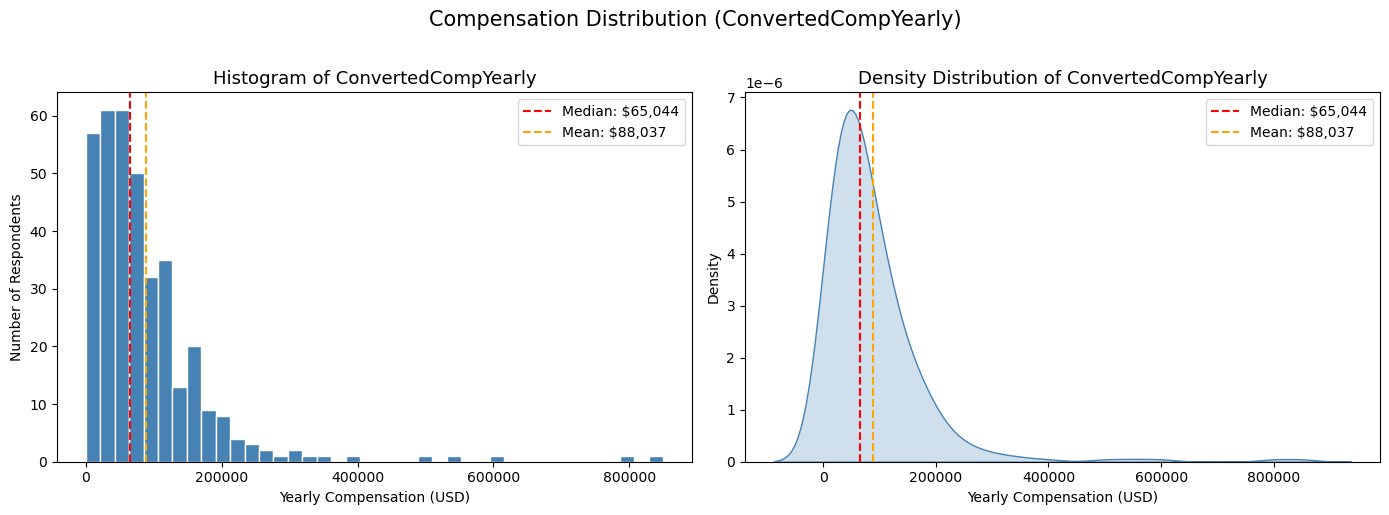


Basic Statistics:
count       366.000000
mean      88036.950820
std       94695.222797
min           1.000000
25%       35469.250000
50%       65044.000000
75%      114741.000000
max      850000.000000
Name: ConvertedCompYearly, dtype: float64

Skewness: 3.94  (positive = right-skewed)


In [3]:
# Drop NaN values for plotting
comp_data = df['ConvertedCompYearly'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Histogram ---
axes[0].hist(comp_data, bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Histogram of ConvertedCompYearly', fontsize=13)
axes[0].set_xlabel('Yearly Compensation (USD)')
axes[0].set_ylabel('Number of Respondents')
axes[0].axvline(comp_data.median(), color='red', linestyle='--', label=f'Median: ${comp_data.median():,.0f}')
axes[0].axvline(comp_data.mean(),   color='orange', linestyle='--', label=f'Mean: ${comp_data.mean():,.0f}')
axes[0].legend()

# --- KDE Distribution Plot ---
sns.kdeplot(comp_data, ax=axes[1], fill=True, color='steelblue')
axes[1].set_title('Density Distribution of ConvertedCompYearly', fontsize=13)
axes[1].set_xlabel('Yearly Compensation (USD)')
axes[1].set_ylabel('Density')
axes[1].axvline(comp_data.median(), color='red',    linestyle='--', label=f'Median: ${comp_data.median():,.0f}')
axes[1].axvline(comp_data.mean(),   color='orange', linestyle='--', label=f'Mean: ${comp_data.mean():,.0f}')
axes[1].legend()

plt.suptitle('Compensation Distribution (ConvertedCompYearly)', fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nBasic Statistics:")
print(comp_data.describe())
print(f"\nSkewness: {comp_data.skew():.2f}  (positive = right-skewed)")

<h3>Step 4: Calculate Median Compensation for Full-Time Employees</h3>


**Task**: Filter the data to calculate the median compensation for respondents whose employment status is "Employed, full-time."


In [4]:
# Filter rows where Employment contains 'Employed, full-time'
# (column can contain multiple values separated by semicolons)
fulltime_df = df[df['Employment'].str.contains('Employed, full-time', na=False)]

median_fulltime = fulltime_df['ConvertedCompYearly'].median()

print(f"Number of full-time employed respondents: {len(fulltime_df)}")
print(f"Median yearly compensation (full-time): ${median_fulltime:,.2f}")

# Overall median for comparison
print(f"Overall median yearly compensation:       ${df['ConvertedCompYearly'].median():,.2f}")

Number of full-time employed respondents: 665
Median yearly compensation (full-time): $64,444.00
Overall median yearly compensation:       $65,044.00


<h3>Step 5: Analyzing Compensation Range and Distribution by Country</h3>


Explore the range of compensation in the ConvertedCompYearly column by analyzing differences across countries. Use box plots to compare the compensation distributions for each country to identify variations and anomalies within each region, providing insights into global compensation trends.


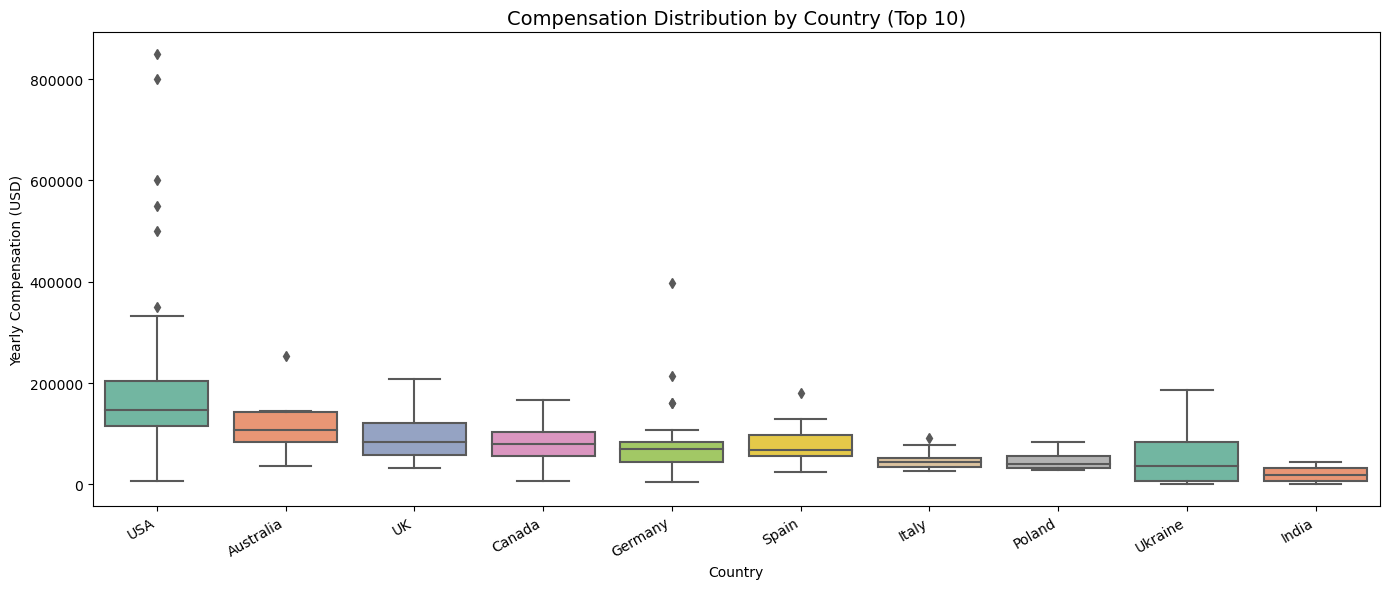


Median Compensation by Country:
Country
USA          $147,000
Australia    $106,532
UK            $84,076
Canada        $79,962
Germany       $69,814
Spain         $67,666
Italy         $44,036
Poland        $40,832
Ukraine       $35,545
India         $17,945


In [5]:
# Focus on the top 10 countries by respondent count for a readable plot
top_countries = df['Country'].value_counts().head(10).index.tolist()
df_top = df[df['Country'].isin(top_countries)].dropna(subset=['ConvertedCompYearly'])

# Shorten long country names for display
country_labels = {
    'United States of America': 'USA',
    'United Kingdom of Great Britain and Northern Ireland': 'UK'
}
df_top = df_top.copy()
df_top['Country'] = df_top['Country'].replace(country_labels)
top_countries_display = [country_labels.get(c, c) for c in top_countries]

# Order countries by median compensation (descending)
order = (df_top.groupby('Country')['ConvertedCompYearly']
               .median()
               .sort_values(ascending=False)
               .index.tolist())

plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_top,
    x='Country',
    y='ConvertedCompYearly',
    order=order,
    palette='Set2',
    showfliers=True
)
plt.title('Compensation Distribution by Country (Top 10)', fontsize=14)
plt.xlabel('Country')
plt.ylabel('Yearly Compensation (USD)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

# Summary table
print("\nMedian Compensation by Country:")
print(df_top.groupby('Country')['ConvertedCompYearly']
           .median()
           .sort_values(ascending=False)
           .apply(lambda x: f"${x:,.0f}")
           .to_string())

<h3>Step 6: Removing Outliers from the Dataset</h3>


**Task**: Create a new DataFrame by removing outliers from the `ConvertedCompYearly` column to get a refined dataset for correlation analysis.


Q1:          $35,469.25
Q3:          $114,741.00
IQR:         $79,271.75
Lower bound: $-83,438.38
Upper bound: $233,648.62

Rows before outlier removal: 1000
Rows after  outlier removal: 350
Outliers removed:            650


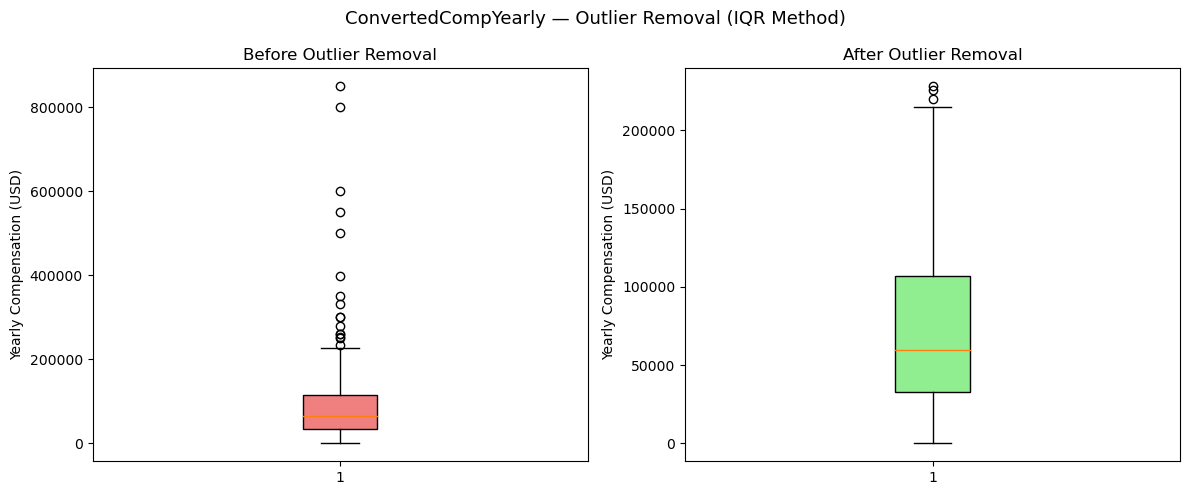

In [6]:
# Use the IQR (Interquartile Range) method to detect and remove outliers
Q1 = df['ConvertedCompYearly'].quantile(0.25)
Q3 = df['ConvertedCompYearly'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"Q1:          ${Q1:,.2f}")
print(f"Q3:          ${Q3:,.2f}")
print(f"IQR:         ${IQR:,.2f}")
print(f"Lower bound: ${lower_bound:,.2f}")
print(f"Upper bound: ${upper_bound:,.2f}")

# Create a refined DataFrame with outliers removed
df_no_outliers = df[
    (df['ConvertedCompYearly'] >= lower_bound) &
    (df['ConvertedCompYearly'] <= upper_bound)
].copy()

print(f"\nRows before outlier removal: {len(df)}")
print(f"Rows after  outlier removal: {len(df_no_outliers)}")
print(f"Outliers removed:            {len(df) - len(df_no_outliers)}")

# Before vs After boxplot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].boxplot(df['ConvertedCompYearly'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightcoral'))
axes[0].set_title('Before Outlier Removal')
axes[0].set_ylabel('Yearly Compensation (USD)')

axes[1].boxplot(df_no_outliers['ConvertedCompYearly'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[1].set_title('After Outlier Removal')
axes[1].set_ylabel('Yearly Compensation (USD)')

plt.suptitle('ConvertedCompYearly — Outlier Removal (IQR Method)', fontsize=13)
plt.tight_layout()
plt.show()

<h3>Step 7: Finding Correlations Between Key Variables</h3>


**Task**: Calculate correlations between `ConvertedCompYearly`, `WorkExp`, and `JobSatPoints_1`. Visualize these correlations with a heatmap.


=== Pearson Correlation Matrix ===
                     ConvertedCompYearly  WorkExp  JobSatPoints_1
ConvertedCompYearly               1.0000   0.3290          0.0809
WorkExp                           0.3290   1.0000          0.0624
JobSatPoints_1                    0.0809   0.0624          1.0000


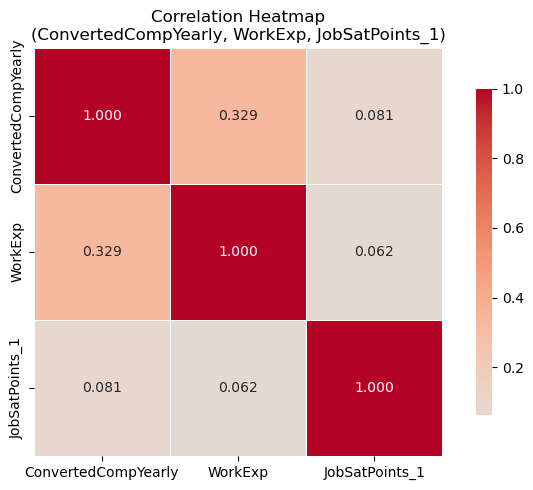

In [7]:
# Select the three columns of interest from the outlier-free DataFrame
corr_cols = ['ConvertedCompYearly', 'WorkExp', 'JobSatPoints_1']
corr_df = df_no_outliers[corr_cols].dropna()

# Compute the Pearson correlation matrix
corr_matrix = corr_df.corr(method='pearson')

print("=== Pearson Correlation Matrix ===")
print(corr_matrix.round(4))

# Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Correlation Heatmap\n(ConvertedCompYearly, WorkExp, JobSatPoints_1)', fontsize=12)
plt.tight_layout()
plt.show()

<h3>Step 8: Scatter Plot for Correlations</h3>


**Task**: Create scatter plots to examine specific correlations between `ConvertedCompYearly` and `WorkExp`, as well as between `ConvertedCompYearly` and `JobSatPoints_1`.


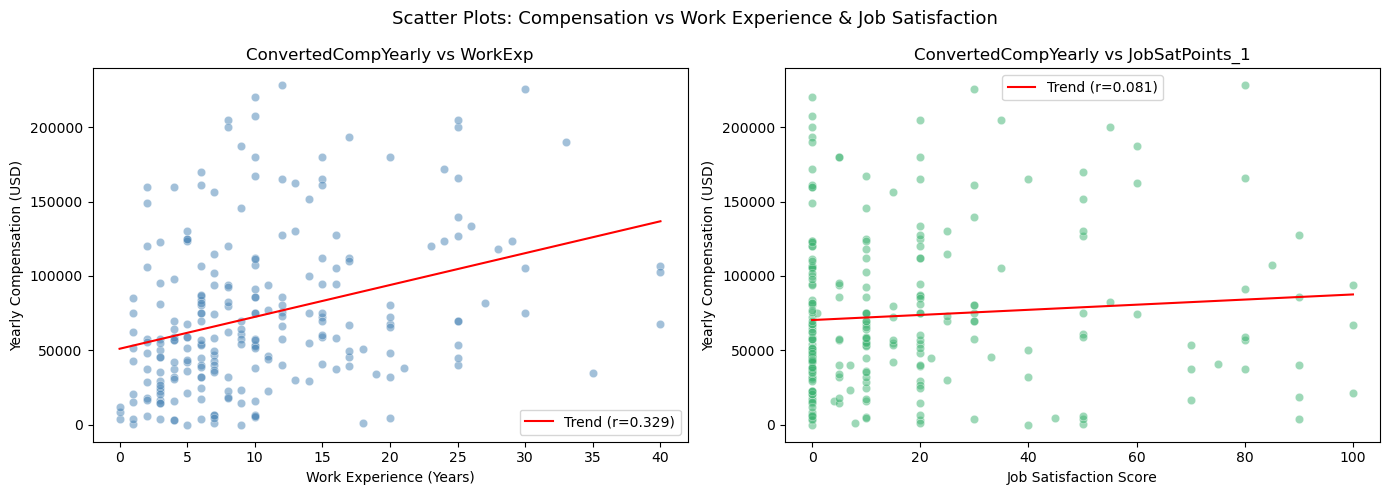

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Plot 1: ConvertedCompYearly vs WorkExp ---
axes[0].scatter(
    corr_df['WorkExp'],
    corr_df['ConvertedCompYearly'],
    alpha=0.5, color='steelblue', edgecolors='white', linewidth=0.4
)
# Add a trend line
m1, b1 = np.polyfit(corr_df['WorkExp'], corr_df['ConvertedCompYearly'], 1)
axes[0].plot(sorted(corr_df['WorkExp']),
             [m1 * x + b1 for x in sorted(corr_df['WorkExp'])],
             color='red', linewidth=1.5, label=f'Trend (r={corr_matrix.loc["ConvertedCompYearly","WorkExp"]:.3f})')
axes[0].set_title('ConvertedCompYearly vs WorkExp', fontsize=12)
axes[0].set_xlabel('Work Experience (Years)')
axes[0].set_ylabel('Yearly Compensation (USD)')
axes[0].legend()

# --- Plot 2: ConvertedCompYearly vs JobSatPoints_1 ---
axes[1].scatter(
    corr_df['JobSatPoints_1'],
    corr_df['ConvertedCompYearly'],
    alpha=0.5, color='mediumseagreen', edgecolors='white', linewidth=0.4
)
# Add a trend line
m2, b2 = np.polyfit(corr_df['JobSatPoints_1'], corr_df['ConvertedCompYearly'], 1)
axes[1].plot(sorted(corr_df['JobSatPoints_1']),
             [m2 * x + b2 for x in sorted(corr_df['JobSatPoints_1'])],
             color='red', linewidth=1.5, label=f'Trend (r={corr_matrix.loc["ConvertedCompYearly","JobSatPoints_1"]:.3f})')
axes[1].set_title('ConvertedCompYearly vs JobSatPoints_1', fontsize=12)
axes[1].set_xlabel('Job Satisfaction Score')
axes[1].set_ylabel('Yearly Compensation (USD)')
axes[1].legend()

plt.suptitle('Scatter Plots: Compensation vs Work Experience & Job Satisfaction', fontsize=13)
plt.tight_layout()
plt.show()

<h3>Summary</h3>


In this lab, you practiced essential skills in correlation analysis by:

- Examining the distribution of yearly compensation with histograms and box plots.
- Detecting and removing outliers from compensation data.
- Calculating correlations between key variables such as compensation, work experience, and job satisfaction.
- Visualizing relationships with scatter plots and heatmaps to gain insights into the associations between these features.

By following these steps, you have developed a solid foundation for analyzing relationships within the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


Copyright © IBM Corporation. All rights reserved.
